In [117]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
font = {"size": 10, "weight": "bold"}
matplotlib.rc("font", **font)

color = matplotlib.cm.viridis(0.3)
color_c = matplotlib.cm.viridis(0.4)
dfs = []
for name in ['standard', 'noise', 'probend', 'probend_noise']:
    df = pd.read_csv('../data/%s_3_processed.csv' % name, index_col=0
                           )
    df['type'] = name
    dfs.append(df)

unique_number_of_seeds = len(dfs[0].seed.unique())
unique_number_of_seeds
file = open('../paper/unique_number_of_seeds.tex', "w")
file.write("{}".format(unique_number_of_seeds))
file.close()

len(dfs[0]['Name'].unique())

file = open('../paper/unique_number_of_strategies.tex', "w")
file.write("{}".format(len(dfs[0]['Name'].unique())))
file.close()

number_of_all_tournaments = sum([len(df.seed.unique()) for df in dfs])

file = open('../paper/number_of_all_tournaments.tex', "w")
file.write("{}".format(number_of_all_tournaments))
file.close()

tournament_types = ['standard', 'noisy', 'probabilistic ending', 'noisy probabilistic ending']

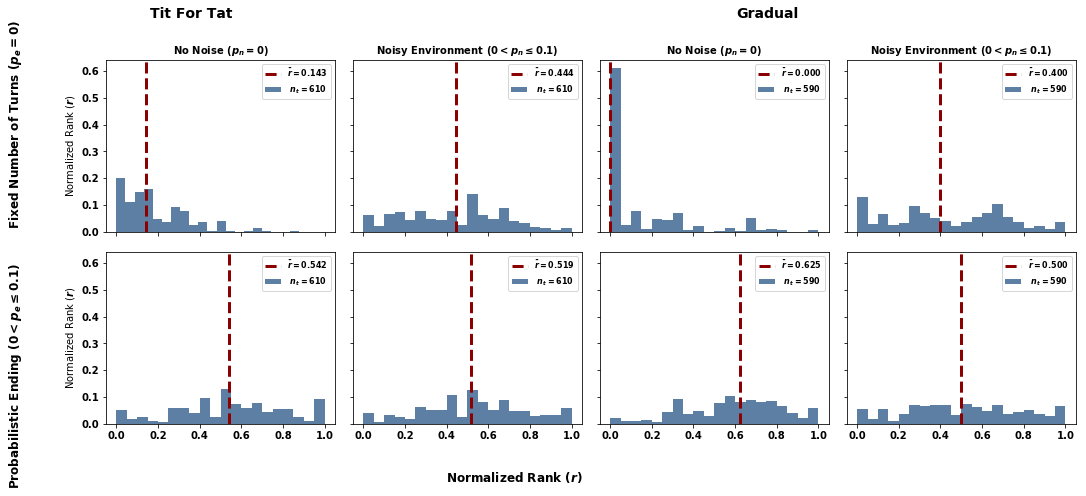

In [118]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ['Tit For Tat', 'Gradual']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 7), sharex=True, sharey=True)

# Axis titles for columns (Noise levels)
titles = [
    'No Noise ($p_n = 0$)', 
    'Noisy Environment ($0 < p_n \\leq 0.1$)'
]

# Assuming dfs is already defined, with 4 DataFrames indexed 0–3

for row in range(2):  # 0 = Fixed turns, 1 = Probabilistic ending
    for col in range(2):  # 0 = No noise, 1 = Noise
        for strat_idx, strategy in enumerate(strategies):  # 0 = TFT, 1 = Gradual
            ax = axes[row, col + strat_idx * 2]  # TFT: cols 0-1, Gradual: cols 2-3
            df_index = row * 2 + col  # Maps to dfs[0–3]
            values = dfs[df_index][dfs[df_index]['Name'] == strategy]['Normalized_Rank'].values
            weights = np.ones_like(values) / len(values) if len(values) > 0 else None

            median_val = np.median(values) if len(values) > 0 else 0
            nt_val = len(values)

            # Create a combined label for histogram with median and n_t
            hist_label = rf'$\ n_t = {nt_val}$'

            ax.hist(values, bins=20, weights=weights, color=color, alpha=0.8, label=hist_label)

            # Median vertical line with legend label
            ax.axvline(median_val, color='darkred', linestyle='--', linewidth=3, label=rf'$\bar{{r}} = {median_val:.3f}$')

            if col + strat_idx * 2 == 0:
                ax.set_ylabel("Normalized Rank ($r$)")

            if row == 0:
                ax.set_title(titles[col], fontsize=10, weight='bold')

            # Show legend with both median and n_t info
            ax.legend(fontsize=8, loc='upper right')

# Strategy section headers
fig.text(0.22, 0.96, 'Tit For Tat', ha='center', fontsize=14, weight='bold')
fig.text(0.72, 0.96, 'Gradual', ha='center', fontsize=14, weight='bold')

# Row labels for tournament types
fig.text(0.06, 0.75, 'Fixed Number of Turns ($p_e = 0$)', va='center', rotation='vertical', fontsize=12)
fig.text(0.06, 0.25, 'Probabilistic Ending ($0 < p_e \\leq 0.1$)', va='center', rotation='vertical', fontsize=12)

# X-axis label
fig.text(0.5, 0.04, 'Normalized Rank ($r$)', ha='center', fontsize=12)

# Layout
plt.tight_layout(rect=[0.1, 0.1, 1, 0.93])
plt.savefig('normalized_rank_distributions.png', dpi=300)
plt.show()



In [119]:
import pandas as pd

average_prfs = []
for df in dfs:
    # Get median Normalized_Rank per strategy Name for this df only once
    average_prfs.append(df.groupby('Name').median()['Normalized_Rank'].round(3))

# Now build the columns for the table (top 15 per tournament type)
columns = []
for prfs in average_prfs:
    columns.append(prfs.sort_values()[:15].index.tolist())   # Top 15 strategy names
    columns.append(prfs.sort_values()[:15].values.tolist())  # Their median normalized ranks

# Create DataFrame from these columns (transpose so rows = rank positions)
table = pd.DataFrame.from_records(columns).T

# Set column names repeating ['Name', '$\\bar{r}$'] for each tournament df
num_tournaments = len(average_prfs)
table.columns = ['Name', r'$\bar{r}$'] * num_tournaments

print(table.head())



                    Name $\bar{r}$                   Name $\bar{r}$  \
0                Gradual         0             Alternator     0.375   
1  Forgiving Tit For Tat     0.143  Forgiving Tit For Tat       0.4   
2            Tit For Tat     0.143                Gradual       0.4   
3            BackStabber       0.2            Tit For Tat     0.444   
4    Win-Stay Lose-Shift       0.4             Cooperator     0.455   

                     Name $\bar{r}$                    Name $\bar{r}$  
0                Defector         0              Alternator       0.3  
1  Suspicious Tit For Tat     0.091  Suspicious Tit For Tat     0.388  
2                  Prober     0.154     Win-Stay Lose-Shift     0.462  
3                  Random     0.222             BackStabber       0.5  
4              Alternator     0.286              Cooperator       0.5  


In [120]:
file = open('../paper/perfomances_table.tex', "w")
file.write(table.to_latex())
file.close()

import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import gaussian_kde

%matplotlib inline

def get_distribution_without_outliers(distribution, percentage=0.1):
    distribution.sort()
    size_of_ditribution = len(distribution)
    outliers = int(size_of_ditribution * (percentage))
    
    return distribution[:-outliers]



def plot_perfomance_violin_plots(df,
                                 top_names,
                                 axes,
                                 ylim_up=1,
                                 remove_outliers=False,
                                 percentage=0.1):
    data, violin_data = [], []
    for name in top_names:
        distribution = df[df['Name'] == name]['Normalized_Rank'].values
        
        data.append(distribution)
        
        if remove_outliers:
            distribution = get_distribution_without_outliers(distribution, percentage)
        violin_data.append(distribution)

    means = [np.mean(dt) for dt in data]

    parts = axes.violinplot(violin_data, showextrema=False,
                            showmeans=False);

    boxes = axes.boxplot(data, showfliers=False)
    axes.scatter(range(1, len(means) + 1), means, marker='o', color='purple', zorder=3, s=50)

    for pc in parts['bodies']:
        pc.set_facecolor('lightsteelblue')
        pc.set_edgecolor('black')
        pc.set_alpha(.60)

    for bp in boxes['medians']:
        bp.set_color('purple')
        bp.set_linewidth(2)
        bp.set_linestyle('-.')
    for bp in boxes['caps']:
        bp.set_color('navy')
        bp.set_linewidth(2)
    for bp in boxes['whiskers']:
        bp.set_color('navy')
        bp.set_linewidth(2)
    for bp in boxes['boxes']:
        bp.set_color('navy')
        bp.set_linewidth(2)

    axes.set_ylabel(r'$r$')
    axes.set_ylim([0, ylim_up]);
    axes.set_xticklabels(list(top_names), rotation=90);

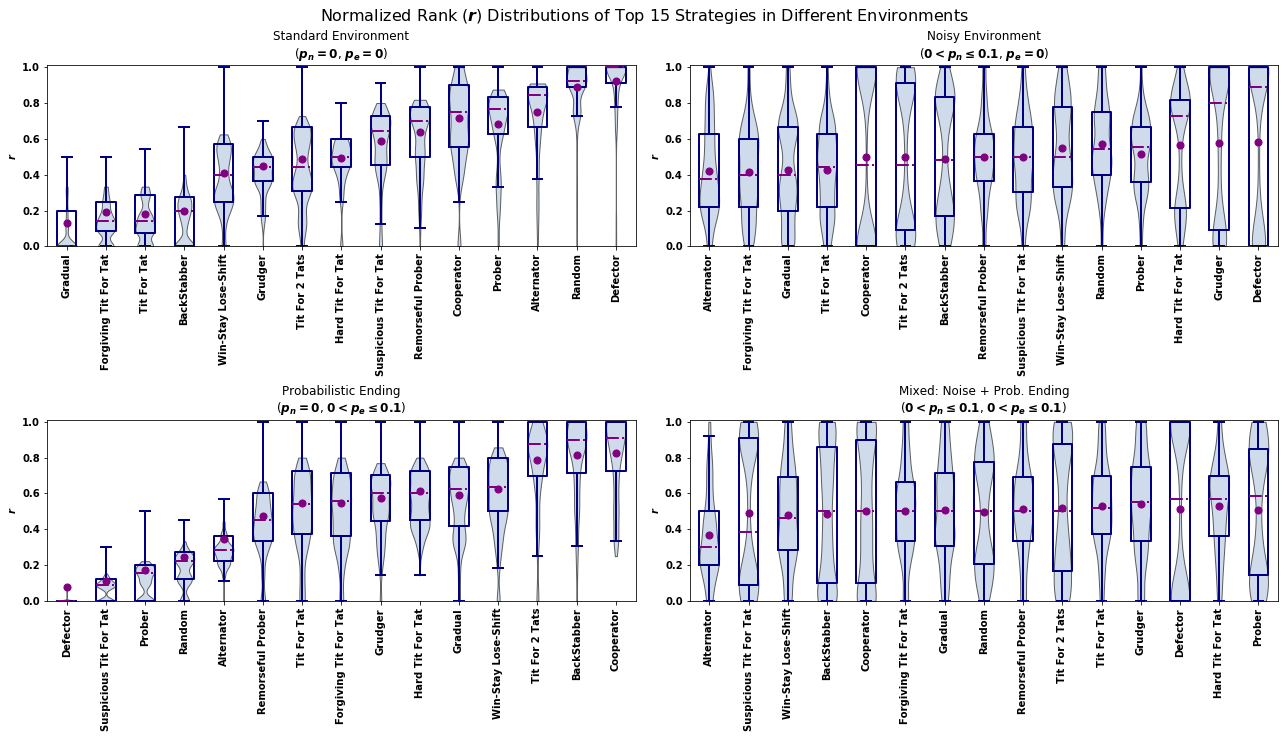

In [121]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))

# --- Upper left: Standard ---
top_names = list(average_prfs[0].sort_values()[:15].index)
plot_perfomance_violin_plots(
    dfs[0],
    top_names,
    axes[0, 0],
    ylim_up=1.01,
    remove_outliers=True,
    percentage=0.15
)
axes[0, 0].set_title('Standard Environment\n($p_n = 0$, $p_e = 0$)', fontsize=12)

# --- Upper right: Noise only ---
top_names_noise = list(average_prfs[1].sort_values()[:15].index)
plot_perfomance_violin_plots(
    dfs[1],
    top_names_noise,
    axes[0, 1],
    ylim_up=1.01
)
axes[0, 1].set_title('Noisy Environment\n($0 < p_n \\leq 0.1$, $p_e = 0$)', fontsize=12)

# --- Lower left: Probabilistic Ending only ---
top_names_probend = list(average_prfs[2].sort_values()[:15].index)
plot_perfomance_violin_plots(
    dfs[2],
    top_names_probend,
    axes[1, 0],
    ylim_up=1.01,
    remove_outliers=True,
    percentage=0.17
)
axes[1, 0].set_title('Probabilistic Ending\n($p_n = 0$, $0 < p_e \\leq 0.1$)', fontsize=12)

# --- Lower right: Probabilistic Ending + Noise ---
top_names_mixed = list(average_prfs[3].sort_values()[:15].index)
plot_perfomance_violin_plots(
    dfs[3],
    top_names_mixed,
    axes[1, 1],
    ylim_up=1.01
)
axes[1, 1].set_title('Mixed: Noise + Prob. Ending\n($0 < p_n \\leq 0.1$, $0 < p_e \\leq 0.1$)', fontsize=12)

# Adjust layout
plt.tight_layout()
fig.suptitle('Normalized Rank ($r$) Distributions of Top 15 Strategies in Different Environments',
             fontsize=16, y=1.02)

# Save the full figure
fig.savefig('r_distribution_all_envs.pdf', bbox_inches='tight')

plt.show()



In [122]:
import pandas as pd

# Export to LaTeX
latex_code = table.to_latex(multicolumn=True, multirow=True, escape=False)

# Save or print the LaTeX code
print(latex_code)
# Or save to file:
with open('strategy_table.tex', 'w') as f:
    f.write(latex_code)



\begin{tabular}{lllllllll}
\toprule
{} &                    Name & $\bar{r}$ &                    Name & $\bar{r}$ &                    Name & $\bar{r}$ &                    Name & $\bar{r}$ \\
\midrule
0  &                 Gradual &         0 &              Alternator &     0.375 &                Defector &         0 &              Alternator &       0.3 \\
1  &   Forgiving Tit For Tat &     0.143 &   Forgiving Tit For Tat &       0.4 &  Suspicious Tit For Tat &     0.091 &  Suspicious Tit For Tat &     0.388 \\
2  &             Tit For Tat &     0.143 &                 Gradual &       0.4 &                  Prober &     0.154 &     Win-Stay Lose-Shift &     0.462 \\
3  &             BackStabber &       0.2 &             Tit For Tat &     0.444 &                  Random &     0.222 &             BackStabber &       0.5 \\
4  &     Win-Stay Lose-Shift &       0.4 &              Cooperator &     0.455 &              Alternator &     0.286 &              Cooperator &       0.5 \\
5  &   

In [132]:
import pandas as pd
from scipy.stats import spearmanr
import imp

plot = imp.load_source('plot', '../src/plot.py')



# Features to analyze
clustering_on = ["Normalized_Rank", "Median_score"]
tables = []

for file in ['standard', 'noise', 'probend', 'probend_noise']:
    df = pd.read_csv(f'../data/{file}_3_processed.csv')

    # Filter to only top strategies
    if file == "standard":
        df = df[df['Name'].isin(top_names)]
    elif file == "noise":
        df = df[df['Name'].isin(top_names_noise)]
    elif file == "probend":
        df = df[df['Name'].isin(top_names_probend)]
    elif file == "probend_noise":
        df = df[df['Name'].isin(top_names_mixed)]

    features = [
        "CC_to_C_rate", "CD_to_C_rate", "DC_to_C_rate", "DD_to_C_rate", "SSE",
        "Makes_use_of_game", "Makes_use_of_length", "Stochastic",
        "Cooperation_rating", "Cooperation_rating_max", "Cooperation_rating_min",
        "Cooperation_rating_median", "Cooperation_rating_mean",
        "Cooperation_rating_comp_to_max", "Cooperation_rating_comp_to_min",
        "Cooperation_rating_comp_to_median", "Cooperation_rating_comp_to_mean",
        "size", "repetitions"
    ]

    if file == "standard":
        features += ["turns", "memory_usage"]
    if file == "noise":
        features += ["noise", "turns", "memory_usage"]
    if file == "probend":
        features += ["probend"]
    if file == "probend_noise":
        features += ["probend", "noise"]

    # Calculate Spearman correlation manually
    corr_results = {}
    for feature in features:
        row = []
        for target in clustering_on:
            corr, _ = spearmanr(df[feature], df[target], nan_policy='omit')
            row.append(round(corr, 3))
        corr_results[plot.features_labels[feature]] = row

    # Create DataFrame with feature labels as index
    table = pd.DataFrame.from_dict(corr_results, orient='index', columns=[r"$\rho(\bar{r})$", r"$\rho(s)$"])
    tables.append(table)

# Concatenate all tables horizontally
final_table = pd.concat(tables, axis=1)

# Rename columns to indicate tournament types
final_table.columns = pd.MultiIndex.from_product([
    ['Standard', r'Noisy ($\mathrm{pn}_{n} \leq 0.1$)', r'Prob. ending ($\mathrm{pe} \leq 0.1$)', r'Noisy + Prob. ending'],
    ["r", "Median Score"]
])
import pandas as pd

# Export to LaTeX
final_latex_code = final_table.to_latex(multicolumn=True, multirow=True, escape=False)

# Save or print the LaTeX code
print(final_latex_code)
# Export to LaTeX
with open('correlation_table_features.tex', 'w') as f:
    f.write(final_latex_code)



\begin{tabular}{lrrrrrrrr}
\toprule
{} & \multicolumn{2}{l}{Standard} & \multicolumn{2}{l}{Noisy ($\mathrm{pn}_{n} \leq 0.1$)} & \multicolumn{2}{l}{Prob. ending ($\mathrm{pe} \leq 0.1$)} & \multicolumn{2}{l}{Noisy + Prob. ending} \\
{} &        r & Median Score &                                  r & Median Score &                                     r & Median Score &                    r & Median Score \\
\midrule
$CC$ to $C$ rate     &   -0.503 &        0.531 &                              0.390 &       -0.481 &                                 0.506 &       -0.413 &                0.206 &        0.101 \\
$CD$ to $C$ rate     &   -0.079 &        0.107 &                              0.277 &        0.019 &                                 0.268 &       -0.121 &                0.166 &       -0.317 \\
$DC$ to $C$ rate     &   -0.123 &        0.109 &                              0.341 &       -0.382 &                                -0.252 &        0.175 &                0.174 &        0.119

In [ ]:
import imp

plot = imp.load_source('plot', '../src/plot.py')

clustering_on = ["Normalized_Rank", "Median_score"]

for file in ['standard', 'noise', 'probend', 'probend_noise']:
    df = pd.read_csv('../data/%s_3_processed.csv' % file)
    
    features = [
        "CC_to_C_rate",
        "CD_to_C_rate",
        "DC_to_C_rate",
        "DD_to_C_rate",
        "SSE",
        "Makes_use_of_game",
        "Makes_use_of_length",
        "Stochastic",
        "Cooperation_rating",
        "Cooperation_rating_max",
        "Cooperation_rating_min",
        "Cooperation_rating_median",
        "Cooperation_rating_mean",
        "Cooperation_rating_comp_to_max",
        "Cooperation_rating_comp_to_min",
        "Cooperation_rating_comp_to_median",
        "Cooperation_rating_comp_to_mean",
        "size",
        "repetitions"
    ]
    
    if file == "standard":
        features += ["turns", "memory_usage"]
    if file == "noise":
        features += ["noise", "turns", "memory_usage"]
    if file == "probend":
        features += ["probend"]
    if file == "probend_noise":
        features += ["probend", "noise"]
    
    corr_data = df[features + clustering_on]
    corrmat = corr_data.corr()
    top_corr_features = corrmat.index
    
    data = corr_data[top_corr_features].corr().round(2)
    data.columns = [plot.features_labels[feature] for feature in data.columns]
    data.index = [plot.features_labels[feature] for feature in corr_data.corr().index]


tables = []
for file in ['standard', 'noise', 'probend', 'probend_noise']:
    df = pd.read_csv('../data/%s_3_processed.csv' % file)
    
    features = [
        "CC_to_C_rate",
        "CD_to_C_rate",
        "DC_to_C_rate",
        "DD_to_C_rate",
        "SSE",
        "Makes_use_of_game",
        "Makes_use_of_length",
        "Stochastic",
        "Cooperation_rating",
        "Cooperation_rating_max",
        "Cooperation_rating_min",
        "Cooperation_rating_median",
        "Cooperation_rating_mean",
        "Cooperation_rating_comp_to_max",
        "Cooperation_rating_comp_to_min",
        "Cooperation_rating_comp_to_median",
        "Cooperation_rating_comp_to_mean",
        "size",
        "repetitions"
    ]
    if file == "standard":
        features += ["turns", "memory_usage"]
    if file == "noise":
        features += ["noise", "turns", "memory_usage"]
    if file == "probend":
        features += ["probend"]
    if file == "probend_noise":
        features += ["probend", "noise"]
    
    corr_data = df[features + clustering_on].corr()
    table = corr_data[clustering_on].iloc[:-2].round(3)
    table.index = [plot.features_labels[index] for index in table.index]
    tables.append(table)

print(table.head())

textfile = open('correlation_table_four_types.tex', 'w')
textfile.write(pd.concat(tables, axis=1).to_latex().replace('\$', '$').replace('\_', '_').replace('\{', '{').replace('\}', '}'))
textfile.close()

                  Normalized_Rank  Median_score
$CC$ to $C$ rate            0.202         0.058
$CD$ to $C$ rate            0.163        -0.274
$DC$ to $C$ rate            0.165         0.096
$DD$ to $C$ rate            0.255        -0.262
SSE                         0.185        -0.257


In [ ]:
import pandas as pd
import statsmodels.api as sm
import imp

# Load plotting module for feature labels
plot = imp.load_source('plot', '../src/plot.py')

# Base features for all tournament types
base_features = [
    "CC_to_C_rate", "CD_to_C_rate", "DC_to_C_rate", "DD_to_C_rate",
    "SSE", "Cooperation_rating", "Cooperation_rating_max", 
    "Cooperation_rating_min", "Cooperation_rating_median",
    "Cooperation_rating_mean", "Cooperation_rating_comp_to_max",
    "Cooperation_rating_comp_to_min", "Cooperation_rating_comp_to_median",
    "Cooperation_rating_comp_to_mean", "repetitions"
]

# Tournament-specific configurations
tournament_configs = {
    'standard': {
        'features': base_features + ["turns", "memory_usage"],
        'remove': ['Cooperation_rating', 'Cooperation_rating_comp_to_median', 
                  'Cooperation_rating_comp_to_max', 'Cooperation_rating_median', 'DD_to_C_rate']
    },
    'noise': {
        'features': base_features + ['noise', 'memory_usage'],
        'remove': ['Cooperation_rating', 'Cooperation_rating_median',
                  'Cooperation_rating_comp_to_median', 'Cooperation_rating_max', 'DD_to_C_rate']
    },
    'probend': {
        'features': base_features + ["probend"],
        'remove': ['Cooperation_rating', 'Cooperation_rating_median',
                  'Cooperation_rating_comp_to_median', 'Cooperation_rating_comp_to_max', 'DD_to_C_rate']
    },
    'probend_noise': {
        'features': base_features + ["probend", "noise"],
        'remove': ['Cooperation_rating', 'Cooperation_rating_median',
                  'Cooperation_rating_comp_to_median', 'Cooperation_rating_comp_to_min',
                  'Cooperation_rating_min', 'noise', 'DD_to_C_rate']
    }
}

# Load all data
dfs = []
for name in tournament_configs.keys():
    df = pd.read_csv(f'../data/{name}_3_processed.csv', index_col=0)
    df['type'] = name
    dfs.append(df)

# Prepare results storage
results = []
r_squared_values = []

# Run regressions for each tournament type
for i, (t_name, config) in enumerate(tournament_configs.items()):
    df = dfs[i]
    
    # Prepare features
    features = [f for f in config['features'] if f not in config['remove']]
    
    # Prepare data
    X = df[features]
    y = df['Median_score']
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X).fit()
    
    # Store R-squared
    r_squared_values.append({
        'Tournament': t_name.replace('_', ' ').title(),
        'R²': model.rsquared.round(3),
        'Adj. R²': model.rsquared_adj.round(3)
    })
    
    # Prepare coefficients table
    coef_table = model.summary2().tables[1][['Coef.', 'P>|t|']]
    coef_table.index = ['constant'] + [plot.features_labels.get(f, f) for f in features]
    coef_table = coef_table.round(3)
    
    # Add tournament type as multiindex
    coef_table.columns = pd.MultiIndex.from_product([[t_name.replace('_', ' ').title()], 
                                                   ['Coefficient', 'p-value']])
    
    results.append(coef_table)

# Create R-squared table
r_squared_df = pd.DataFrame(r_squared_values).set_index('Tournament')

# Combine all coefficient tables
final_table = pd.concat(results, axis=1)

# Generate LaTeX output
# Generate LaTeX output
latex_rows = final_table.to_latex(escape=False, header=False, multicolumn_format='c').split('\n')
# Remove the first and last lines (tabular environment)
latex_body = '\n'.join(latex_rows[2:-2])

latex_output = f"""
\\begin{{tabular}}{{l{'cc' * len(tournament_configs)}}}
\\toprule
 & \\multicolumn{{2}}{{c}}{{Standard}} & \\multicolumn{{2}}{{c}}{{Noise}} & \\multicolumn{{2}}{{c}}{{Probend}} & \\multicolumn{{2}}{{c}}{{Probend Noise}} \\\\
\\cmidrule(lr){{2-3}} \\cmidrule(lr){{4-5}} \\cmidrule(lr){{6-7}} \\cmidrule(lr){{8-9}}
Feature & Coef. & p-value & Coef. & p-value & Coef. & p-value & Coef. & p-value \\\\
\\midrule
{latex_body}
\\midrule
\\multicolumn{{9}}{{l}}{{Model Fit Statistics:}} \\\\
R² & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Standard', 'R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Noise', 'R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Probend', 'R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Probend Noise', 'R²']}}} \\\\
Adj. R² & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Standard', 'Adj. R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Noise', 'Adj. R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Probend', 'Adj. R²']}}} & \\multicolumn{{2}}{{c}}{{{r_squared_df.loc['Probend Noise', 'Adj. R²']}}} \\\\
\\bottomrule
\\end{{tabular}}
"""

# Clean up LaTeX special characters
latex_output = latex_output.replace('\$', '$').replace('\_', '_')

# Save to file
with open('regression_results_with_r_squared.tex', 'w') as f:
    f.write(latex_output)

print("LaTeX table saved to 'regression_results_with_r_squared.tex'")
print("\nR-squared values:")
print(r_squared_df)

LaTeX table saved to 'regression_results_with_r_squared.tex'

R-squared values:
                  R²  Adj. R²
Tournament                   
Standard       0.654    0.654
Noise          0.639    0.638
Probend        0.816    0.816
Probend Noise  0.866    0.865


In [141]:
import matplotlib.pyplot as plt
import matplotlib

font = {"size": 15, "weight": "bold"}
matplotlib.rc("font", **font)


import numpy as np
import pandas as pd

import imp

plot = imp.load_source('plot', '../src/plot.py')

color = matplotlib.cm.viridis(0.2)
color_c = matplotlib.cm.viridis(0.4)
color_sse = matplotlib.cm.viridis(0.3)

colors = [color, color_c, color_sse]

std = pd.read_csv('../data/standard_3_processed.csv', index_col=0)

winners = std[std['Normalized_Rank'] == 0]

noisy = pd.read_csv('../data/noise_3_processed.csv', index_col=0)

winners_noisy = noisy[noisy['Normalized_Rank'] == 0]

titles = ['Noisy tournament', 'Probabilistic ending tournament']

probend = pd.read_csv('../data/probend_3_processed.csv', index_col=0)

winners_probend = probend[probend['Normalized_Rank'] == 0]

probend_noisy = pd.read_csv('../data/probend_noise_3_processed.csv', index_col=0)

winners_probend_noisy = probend_noisy[probend_noisy['Normalized_Rank'] == 0]

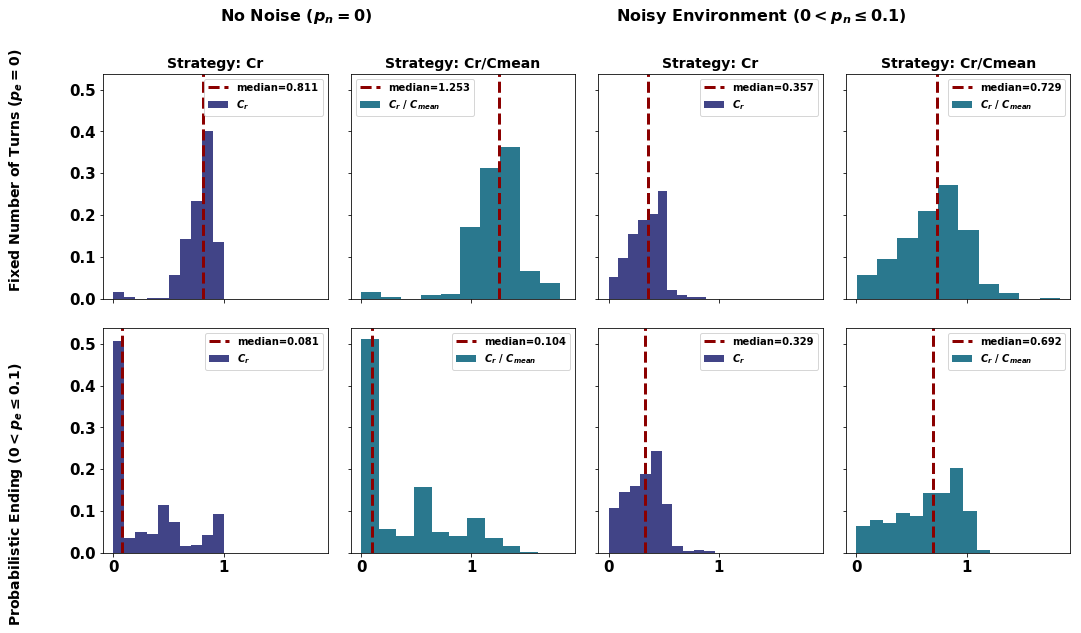

In [147]:
strategies = ['Cr', 'Cr/Cmean']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9), sharex=True, sharey=True)

noise_titles = ['No Noise ($p_n = 0$)', 'Noisy Environment ($0 < p_n \\leq 0.1$)']

df_grid = [
    [winners, winners_noisy],            
    [winners_probend, winners_probend_noisy]
]

for row in range(2):
    for col in range(4):
        ax = axes[row, col]

        noise_idx = 0 if col < 2 else 1
        strat_idx = col % 2  # 0=Cr, 1=Cr/Cmean

        df = df_grid[row][noise_idx]

        if strategies[strat_idx] == 'Cr':
            values = df['Cooperation_rating']
            color = colors[0]
            label = plot.features_labels['Cooperation_rating']
        else:
            rate = 'Cooperation_rating_comp_to_mean'
            values = df[rate]
            color = colors[1]
            label = plot.features_labels[rate]

        weights = np.ones_like(values) / len(values)
        ax.hist(values, weights=weights, color=color, label=label)
        ax.axvline(np.median(values), color="darkred", linestyle="dashed", linewidth=3,
                   label=f"median={np.median(values):.3f}")
        ax.legend(fontsize=10)

        # Set individual subplot titles for strategies only
        if row == 0:
            strat_label = 'Cr' if strat_idx == 0 else 'Cr/Cmean'
            ax.set_title(f"Strategy: {strat_label}", fontweight="bold", fontsize=14)

# Add big noise labels centered over pairs of columns
# Get axes positions to compute midpoints
pos_col0 = axes[0,0].get_position()
pos_col1 = axes[0,1].get_position()
pos_col2 = axes[0,2].get_position()
pos_col3 = axes[0,3].get_position()

# Midpoint x coords for the groups of two columns
mid_no_noise = (pos_col0.x0 + pos_col1.x1) / 2
mid_noisy = (pos_col2.x0 + pos_col3.x1) / 2

fig.text(mid_no_noise, 0.98, noise_titles[0], ha='center', fontsize=16, weight='bold')
fig.text(mid_noisy, 0.98, noise_titles[1], ha='center', fontsize=16, weight='bold')

# Row labels for tournament types
fig.text(0.06, 0.75, 'Fixed Number of Turns ($p_e = 0$)', va='center', rotation='vertical', fontsize=14)
fig.text(0.06, 0.25, 'Probabilistic Ending ($0 < p_e \\leq 0.1$)', va='center', rotation='vertical', fontsize=14)



plt.tight_layout(rect=[0.1, 0.1, 1, 0.95])  # leave space at top for big noise titles
plt.savefig('Distributions_of_Cr_and_Cr_Cmean.png', dpi=300)
plt.show()

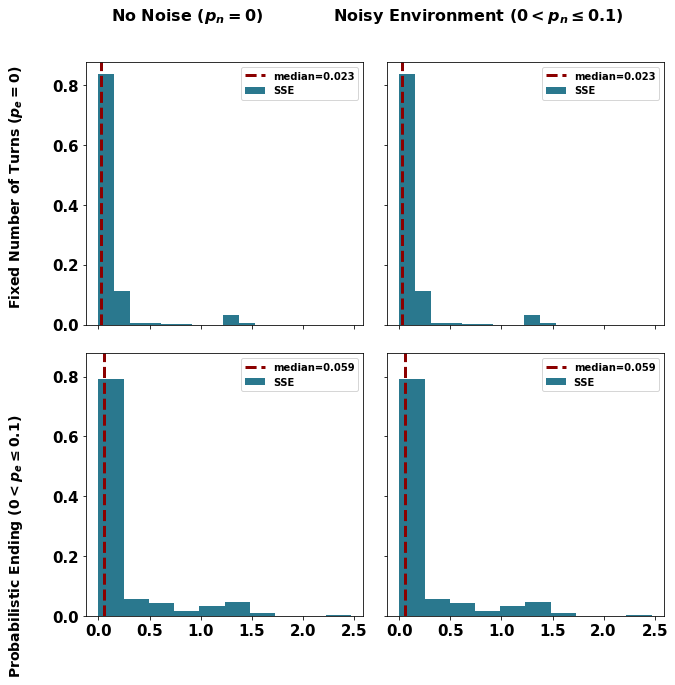

In [148]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True, sharey=True)

noise_titles = ['No Noise ($p_n = 0$)', 'Noisy Environment ($0 < p_n \\leq 0.1$)']

df_grid = [
    [winners, winners_noisy],            
    [winners_probend, winners_probend_noisy]
]

for row in range(2):
    for col in range(2):
        ax = axes[row, col]

        noise_idx = 0 if col < 2 else 1
        strat_idx = col % 2  # 0=Cr, 1=Cr/Cmean

        df = df_grid[row][noise_idx]


        values = df['SSE']
        color = colors[1]
        label = plot.features_labels['SSE']

        weights = np.ones_like(values) / len(values)
        ax.hist(values, weights=weights, color=color, label=label)
        ax.axvline(np.median(values), color="darkred", linestyle="dashed", linewidth=3,
                   label=f"median={np.median(values):.3f}")
        ax.legend(fontsize=10)





fig.text(mid_no_noise, 0.98, noise_titles[0], ha='center', fontsize=16, weight='bold')
fig.text(mid_noisy, 0.98, noise_titles[1], ha='center', fontsize=16, weight='bold')

# Row labels for tournament types
fig.text(0.06, 0.75, 'Fixed Number of Turns ($p_e = 0$)', va='center', rotation='vertical', fontsize=14)
fig.text(0.06, 0.25, 'Probabilistic Ending ($0 < p_e \\leq 0.1$)', va='center', rotation='vertical', fontsize=14)



plt.tight_layout(rect=[0.1, 0.1, 1, 0.95])  # leave space at top for big noise titles
plt.savefig('Distributions_of_SSE.png', dpi=300)
plt.show()

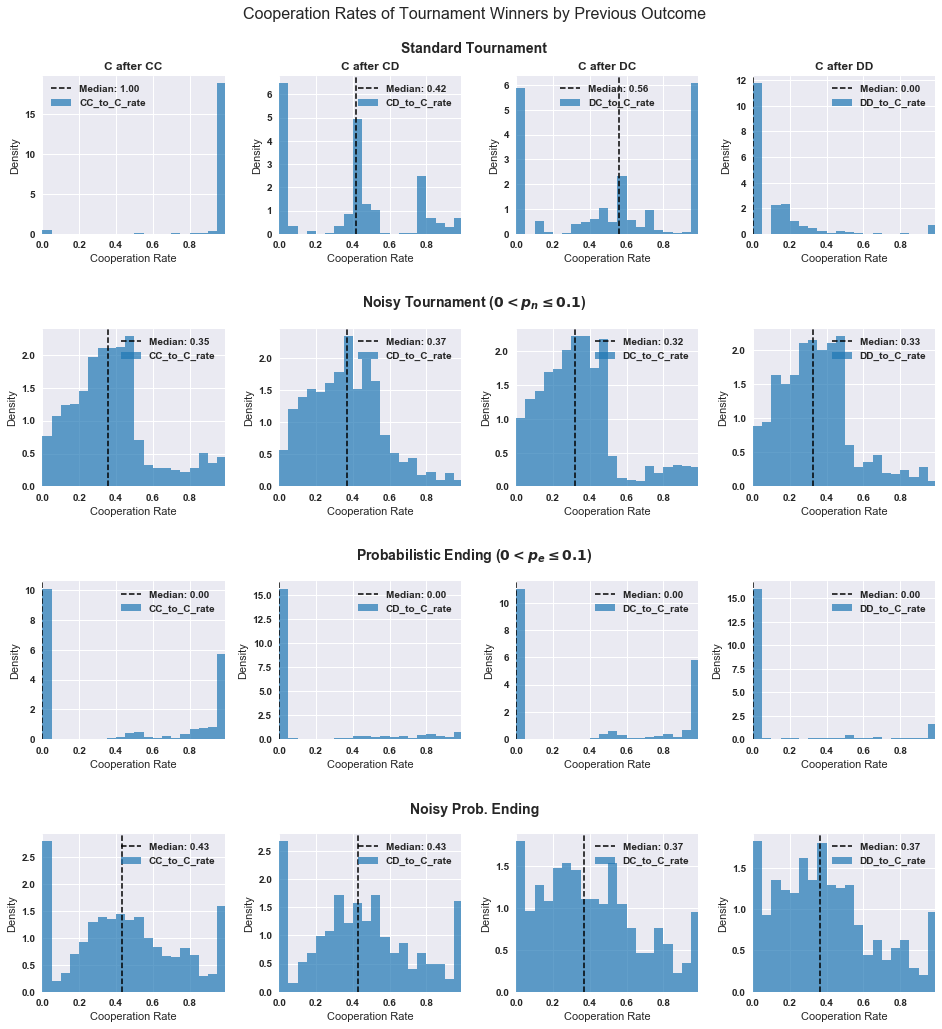

In [169]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import imp

# Set up plotting style
plt.style.use('seaborn')
font = {"size": 12, "weight": "bold"}
matplotlib.rc("font", **font)

# Load plotting module for feature labels
plot = imp.load_source('plot', '../src/plot.py')

# Define a single color for all histograms
hist_color = '#1f77b4'

# Load all tournament data and get winners (Normalized_Rank == 0)
tournament_types = ['standard', 'noise', 'probend', 'probend_noise']
winners = {}

for ttype in tournament_types:
    df = pd.read_csv(f'../data/{ttype}_3_processed.csv', index_col=0)
    winners[ttype] = df[df['Normalized_Rank'] == 0]

# Create figure with 4 rows (tournament types) and 4 columns (outcome types)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 16))
plt.subplots_adjust(hspace=0.6, wspace=0.3, top=0.92)

# Define the rates to plot in order
rate_types = ['CC_to_C_rate', 'CD_to_C_rate', 'DC_to_C_rate', 'DD_to_C_rate']
rate_labels = {
    'CC_to_C_rate': 'C after CC',
    'CD_to_C_rate': 'C after CD',
    'DC_to_C_rate': 'C after DC',
    'DD_to_C_rate': 'C after DD'
}

# Tournament titles
tournament_titles = [
    'Standard Tournament',
    'Noisy Tournament ($0 < p_n \\leq 0.1$)',
    'Probabilistic Ending ($0 < p_e \\leq 0.1$)',
    'Noisy Prob. Ending'
]

# Plot distributions
for row, ttype in enumerate(tournament_types):
    for col, rate in enumerate(rate_types):
        ax = axes[row, col]
        data = winners[ttype][rate].dropna()
        
        # Plot histogram
        ax.hist(data, bins=20, range=(0, 1), 
               color=hist_color, alpha=0.7, 
               density=True)
        
        # Add median line
        median_val = np.median(data)
        ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5,
                  label=f'Median: {median_val:.2f}')
        
        # Set titles and labels
        if row == 0:
            ax.set_title(rate_labels[rate], fontweight='bold')
        ax.set_xlabel('Cooperation Rate')
        ax.set_ylabel('Density')
        ax.set_xlim(0, 0.99)
        ax.legend()

# Add tournament labels centered above each row
for i, title in enumerate(tournament_titles):
    fig.text(0.5, 0.94 - i * 0.22, title, ha='center', fontsize=14, weight='bold')

# Overall figure title
fig.suptitle('Cooperation Rates of Tournament Winners by Previous Outcome', 
             fontsize=16, y=0.98)

# Save and show figure
plt.savefig('winner_cooperation_rates.png', dpi=300, bbox_inches='tight')
plt.show()
